In [1]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42

%matplotlib widget

In [2]:
df_train = pd.read_csv(f"data-01-processed/lgb_regression_train.csv", index_col=[0])

df_train

,temp,atemp,hum,wind,wcond,temp_sq,hum_sq,wind_sq,temp_x_hum,temp_x_wind,...,weekend,dayofyear,quarter,sin_doy_1,cos_doy_1,sin_doy_2,cos_doy_2,sin_doy_3,cos_doy_3,count
1,9.1,13.2,79.78,10.43,2,82.81,6364.8484,108.7849,725.998,94.913,...,1,1,1,1.721336e-02,0.999852,3.442161e-02,0.999407,5.161967e-02,0.998667,982
2,9.9,12.7,68.91,16.16,2,98.01,4748.5881,261.1456,682.209,159.984,...,1,2,1,3.442161e-02,0.999407,6.880243e-02,0.997630,1.031017e-01,0.994671,797
3,3.1,4.5,43.29,16.14,1,9.61,1874.0241,260.4996,134.199,50.034,...,0,3,1,5.161967e-02,0.998667,1.031017e-01,0.994671,1.543088e-01,0.988023,1351
4,3.2,5.6,58.45,10.42,1,10.24,3416.4025,108.5764,187.040,33.344,...,0,4,1,6.880243e-02,0.997630,1.372788e-01,0.990532,2.051045e-01,0.978740,1559
5,4.3,6.5,43.26,12.15,1,18.49,1871.4276,147.6225,186.018,52.245,...,0,5,1,8.596480e-02,0.996298,1.712931e-01,0.985220,2.553533e-01,0.966848,1597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,8.3,11.4,75.49,12.25,2,68.89,5698.7401,150.0625,626.567,101.675,...,0,361,4,-6.880243e-02,0.997630,-1.372788e-01,0.990532,-2.051045e-01,0.978740,1161
362,7.3,9.0,49.89,19.11,1,53.29,2489.0121,365.1921,364.197,139.503,...,0,362,4,-5.161967e-02,0.998667,-1.031017e-01,0.994671,-1.543088e-01,0.988023,2301
363,5.2,8.2,56.84,7.76,1,27.04,3230.7856,60.2176,295.568,40.352,...,0,363,4,-3.442161e-02,0.999407,-6.880243e-02,0.997630,-1.031017e-01,0.994671,2421
364,7.8,10.9,63.03,8.73,1,60.84,3972.7809,76.2129,491.634,68.094,...,0,364,4,-1.721336e-02,0.999852,-3.442161e-02,0.999407,-5.161967e-02,0.998667,2995


# Cross Validation

In [3]:
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from scripts.find_solve_regression import cross_validate_regression

In [4]:
X = df_train[[col for col in df_train.columns if col != "count"]].to_numpy()

y = df_train["count"].to_numpy()

alphas = np.logspace(-2, np.log10(4), 1000)
l1_ratios = [0.25]

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [5]:
results = cross_validate_regression(
    X = X,
    y = y,
    regressor_class=ElasticNet,
    param_grid={
        "alpha": alphas, 
        "l1_ratio": [0.5], 
        "max_iter": [10000],
    },
    kf = kf,
)

[Fold]: 0
[Fold]: 1
[Fold]: 2
[Fold]: 3
[Fold]: 4


In [6]:
results["best_params"]

{'alpha': np.float64(0.01), 'l1_ratio': 0.5, 'max_iter': 10000}

# Visualizing MSEs

In [7]:
from scripts.plot_regression import plot_cv_results

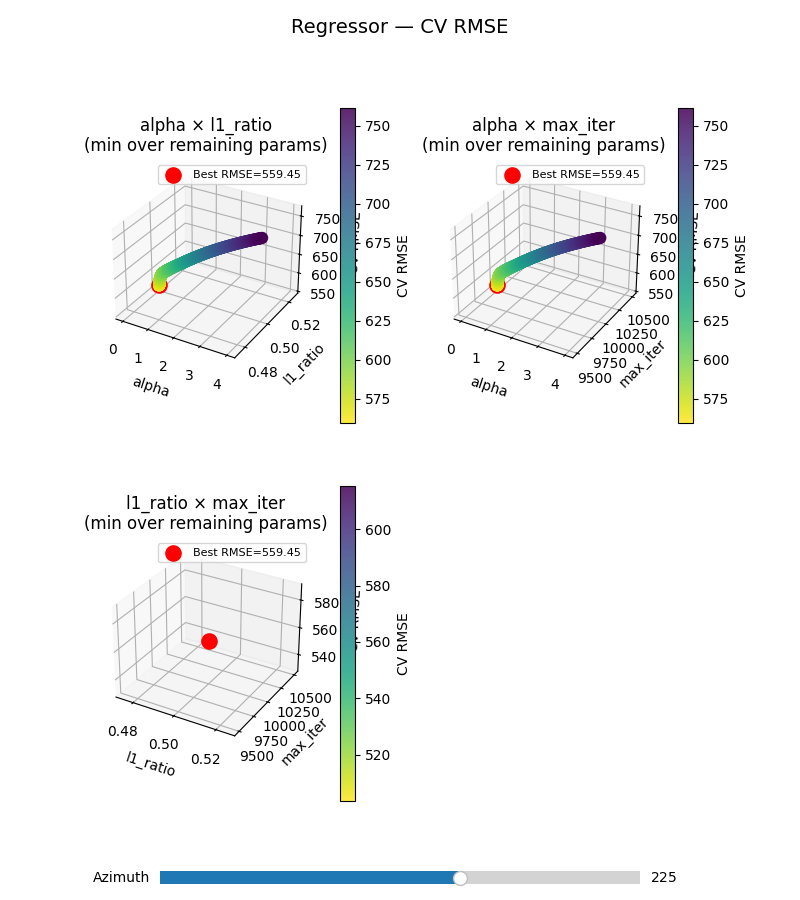

In [8]:
plot_cv_results(
    param_grid={
        "alpha": alphas, 
        "l1_ratio": l1_ratios, 
        "max_iter": [10000],
    },
    cv_results=results,
)

# Fitting Best Model

In [9]:
from scripts.find_solve_regression import fit_final_regression

In [ ]:
model, scaler = fit_final_regression(
    X, 
    y, 
    regressor_class=ElasticNet,
    params={
        "alpha": 1,
        "l1_ratio": 0,
        "max_iter": 10_000
    }
    )

In [17]:
df_test = pd.read_csv(f"data-01-processed/lgb_regression_test.csv", index_col=[0])

df_test_with_date = pd.read_csv(f"data-00-raw/bike_test.csv", index_col=[0])

In [18]:
preds = model.predict(scaler.transform(df_test.to_numpy()))

# Submission Generator

In [19]:
from scripts.save_submission import save_submission_csv

In [20]:
df_submission = pd.DataFrame({"date": df_test_with_date["date"], "pred": preds})

df_submission

,date,pred
1,2023-01-01,2207.241602
2,2023-01-02,1741.715921
3,2023-01-03,1128.059677
4,2023-01-04,1310.008573
5,2023-01-05,2133.479321
...,...,...
361,2023-12-27,1374.377283
362,2023-12-28,1859.097131
363,2023-12-29,2495.345766
364,2023-12-30,2281.191641


In [21]:
save_submission_csv(df_submission)